In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\shrey\Downloads\loan_applicants_dataset.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              5000 non-null   object 
 1   Name                     5000 non-null   object 
 2   Age                      5000 non-null   int64  
 3   Gender                   5000 non-null   object 
 4   Marital_Status           5000 non-null   object 
 5   Employment_Type          5000 non-null   object 
 6   Monthly_Income           5000 non-null   int64  
 7   Loan_Amount_Requested    5000 non-null   int64  
 8   Credit_Score             5000 non-null   int64  
 9   Existing_EMI             5000 non-null   int64  
 10  Loan_Tenure_Years        5000 non-null   int64  
 11  Dependents               5000 non-null   int64  
 12  Bank_Statement_Verified  5000 non-null   object 
 13  Voice_Verified           5000 non-null   object 
 14  Document_Verified       

,Age,Monthly_Income,Loan_Amount_Requested,Credit_Score,Existing_EMI,Loan_Tenure_Years,Dependents,Total_Liabilities,Past_Defaults,Total_Withdrawals,Total_Deposits,Avg_Balance,Bounced_Transactions,Account_Age_Months,Debt_to_Income_Ratio,Eligibility_Score,Loan_Approved
count,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.194600,109901.956600,1.044021e+06,604.903200,24812.928400,7.535600,1.512200,402805.913000,0.309200,524931.496600,6.433624e+05,78548.635600,2.51520,62.273000,0.321278,0.638480,0.634200
std,11.210025,52269.941155,5.473586e+05,172.483729,14652.471682,4.011228,1.109638,231582.570054,0.559695,273338.837076,3.228150e+05,41884.955258,1.72301,33.282644,0.337507,0.143855,0.481702
min,21.000000,20018.000000,1.000560e+05,300.000000,10.000000,1.000000,0.000000,27.000000,0.000000,50205.000000,8.023300e+04,5163.000000,0.00000,6.000000,0.000000,0.170000,0.000000
25%,31.000000,64708.250000,5.763775e+05,456.000000,11963.250000,4.000000,1.000000,201596.500000,0.000000,289594.000000,3.645425e+05,42157.000000,1.00000,33.000000,0.110000,0.560000,0.000000
50%,40.000000,110766.500000,1.042702e+06,608.500000,24562.000000,8.000000,2.000000,409679.000000,0.000000,523356.000000,6.428490e+05,79245.500000,3.00000,62.000000,0.230000,0.650000,1.000000
75%,50.000000,155121.500000,1.511704e+06,755.000000,37659.500000,11.000000,3.000000,603388.750000,1.000000,764592.250000,9.237385e+05,114746.250000,4.00000,92.000000,0.390000,0.740000,1.000000
max,59.000000,199937.000000,1.999791e+06,900.000000,49985.000000,14.000000,3.000000,799984.000000,3.000000,999865.000000,1.199943e+06,149991.000000,5.00000,119.000000,2.360000,0.960000,1.000000


In [2]:
df = df.drop(columns=['Customer_ID', 'Name', 'Eligibility_Score'], errors='ignore')

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes('object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.968
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       368
           1       0.97      0.98      0.97       632

    accuracy                           0.97      1000
   macro avg       0.97      0.96      0.97      1000
weighted avg       0.97      0.97      0.97      1000



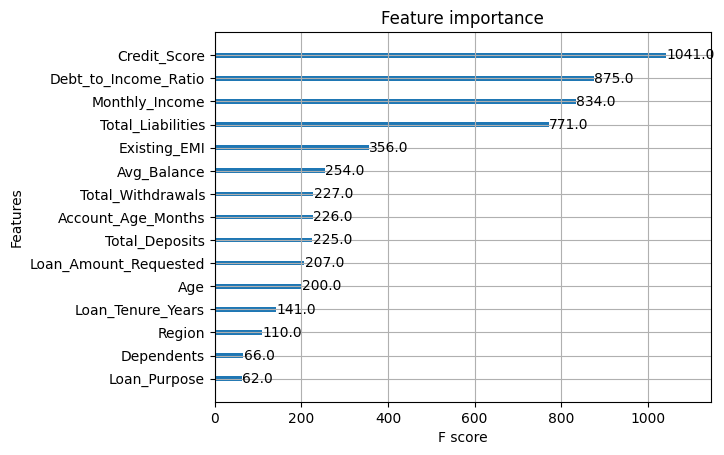

In [6]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model, max_num_features=15)
plt.show()


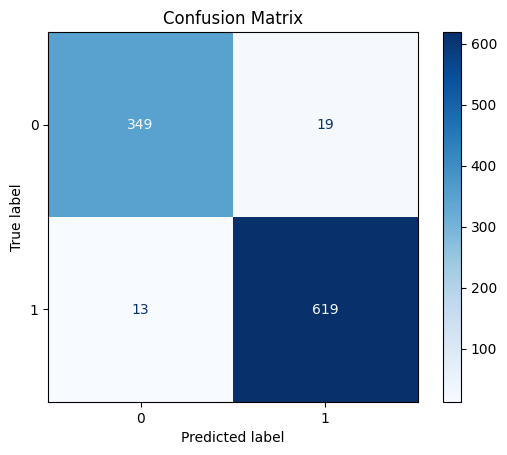

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


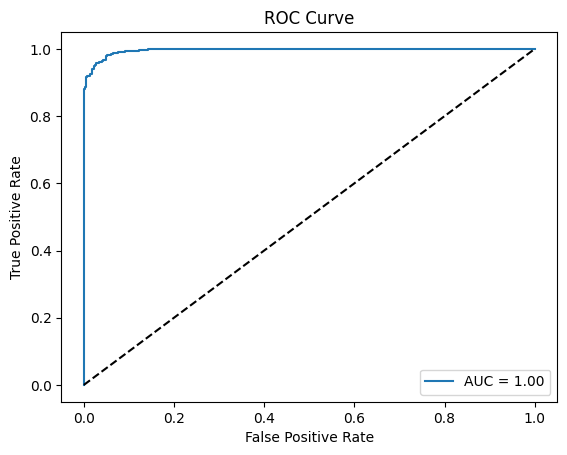

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

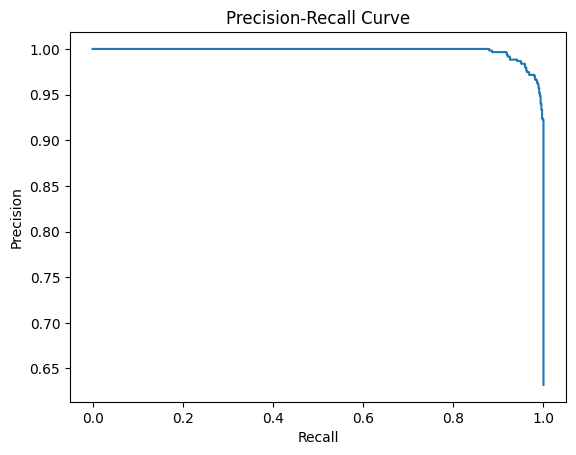

In [9]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

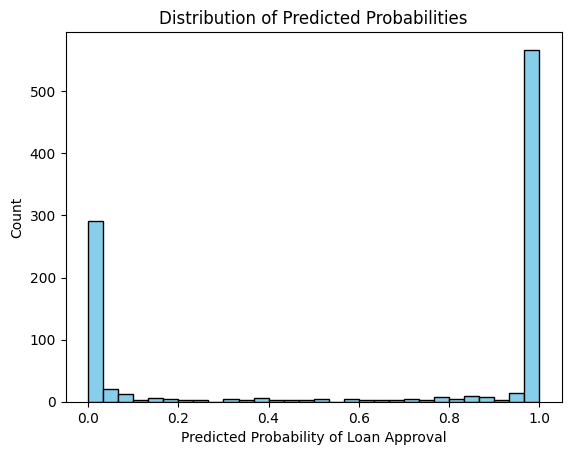

In [10]:
plt.hist(y_pred_prob, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability of Loan Approval")
plt.ylabel("Count")
plt.show()


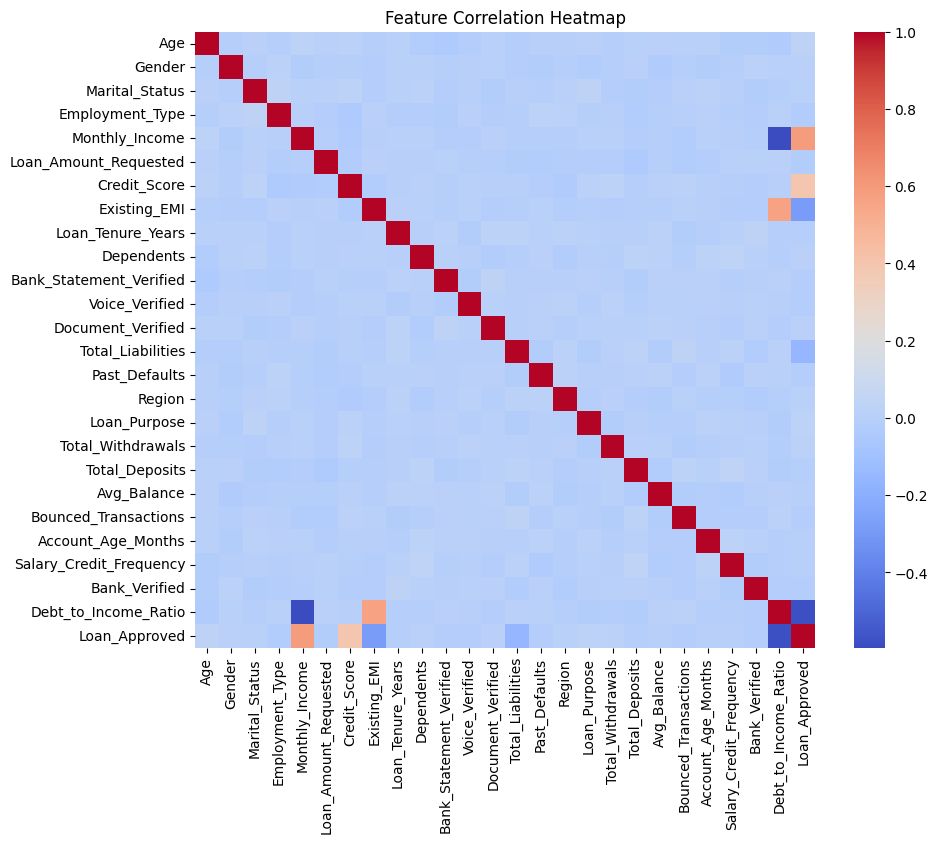

In [11]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


In [12]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [17]:
import joblib
import os
folder_path = r"C:\Users\shrey\Infosys_project"


columns_path = os.path.join(folder_path, "X_columns.pkl")
joblib.dump(list(X_train.columns), columns_path)
print(f"✅ Columns saved at: {columns_path}")


✅ Columns saved at: C:\Users\shrey\Infosys_project\X_columns.pkl


In [18]:
from sklearn.inspection import permutation_importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)



In [19]:
result.importances_mean[:10]

array([ 3.000e-04,  1.000e-04, -4.000e-04,  1.400e-03,  1.811e-01,
        5.000e-04,  1.947e-01,  2.900e-03,  5.000e-04, -8.000e-04])

In [20]:
for feature, importance in zip(X_test.columns, result.importances_mean):
    print(f"{feature}: {importance:.4f}")

Age: 0.0003
Gender: 0.0001
Marital_Status: -0.0004
Employment_Type: 0.0014
Monthly_Income: 0.1811
Loan_Amount_Requested: 0.0005
Credit_Score: 0.1947
Existing_EMI: 0.0029
Loan_Tenure_Years: 0.0005
Dependents: -0.0008
Bank_Statement_Verified: 0.0003
Voice_Verified: 0.0000
Document_Verified: 0.0000
Total_Liabilities: 0.0653
Past_Defaults: -0.0003
Region: -0.0012
Loan_Purpose: 0.0000
Total_Withdrawals: 0.0013
Total_Deposits: 0.0019
Avg_Balance: 0.0003
Bounced_Transactions: -0.0006
Account_Age_Months: -0.0020
Salary_Credit_Frequency: 0.0000
Bank_Verified: 0.0000
Debt_to_Income_Ratio: 0.1816


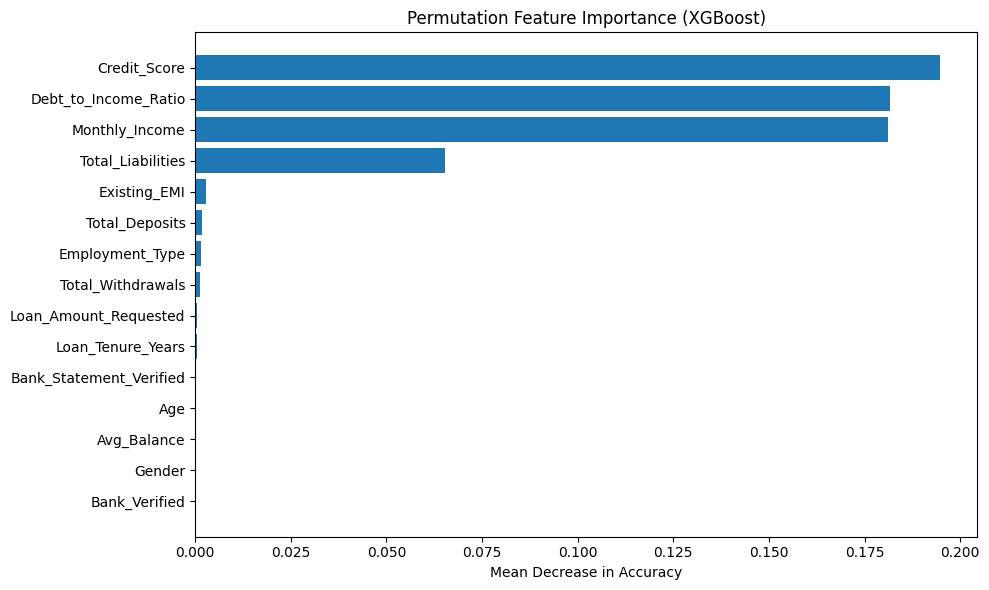

In [21]:
import matplotlib.pyplot as plt
import numpy as np

sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[sorted_idx][-15:], result.importances_mean[sorted_idx][-15:])
plt.xlabel("Mean Decrease in Accuracy")
plt.title("Permutation Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()

In [22]:
import os
import pandas as pd
import joblib
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# 1. Create folder to save models
# -----------------------------
folder_path = r"C:\Users\shrey\Infosys_project"

os.makedirs(folder_path, exist_ok=True)

# -----------------------------
# 2. Train model
# -----------------------------
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)
print("✅ Model trained successfully!")

# Save trained model
model_path = os.path.join(folder_path, "loan_xgboost_model.pkl")
joblib.dump(model, model_path)
print(f"✅ Model saved at: {model_path}")

# -----------------------------
# 3. Save LabelEncoders
# -----------------------------
cat_cols = ["Gender","Marital_Status","Employment_Type","Bank_Statement_Verified",
            "Voice_Verified","Document_Verified","Region","Loan_Purpose",
            "Salary_Credit_Frequency","Bank_Verified"]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(X_train[col])
    encoders[col] = le

encoders_path = os.path.join(folder_path, "label_encoders.pkl")
joblib.dump(encoders, encoders_path)
print(f"✅ Encoders saved at: {encoders_path}")

# -----------------------------
# 4. Predict new applicants
# -----------------------------
def preprocess_new_applicants(df_new, encoders, feature_columns):
    # Apply label encoding safely
    for col, le in encoders.items():
        if col in df_new.columns:
            df_new[col] = df_new[col].map(lambda s: s if s in le.classes_ else le.classes_[0])
            df_new[col] = le.transform(df_new[col])

    # Add any missing columns from training with default value 0
    for col in feature_columns:
        if col not in df_new.columns:
            df_new[col] = 0

    # Reorder columns to match training
    df_new = df_new[feature_columns]
    return df_new

# Example usage
new_applicants = pd.DataFrame([{
    "Age": 30,
    "Gender": "Male",
    "Marital_Status": "Single",
    "Employment_Type": "Salaried",
    "Monthly_Income": 45000,
    "Credit_Score": 750,
    "Loan_Amount_Requested": 500000,
    "Existing_EMI": 0,
    "Loan_Tenure_Years": 5,
    "Dependents": 0,
    "Bank_Statement_Verified": "Yes",
    "Voice_Verified": "Yes",
    "Document_Verified": "Yes",
    "Total_Liabilities": 100000,
    "Past_Defaults": 0,
    "Region": "Urban",
    "Loan_Purpose": "Home",
    "Total_Withdrawals": 30000,
    "Total_Deposits": 60000,
    "Avg_Balance": 20000,
    "Bounced_Transactions": 0,
    "Account_Age_Months": 24,
    "Salary_Credit_Frequency": "Monthly",
    "Bank_Verified": "Yes",
    "Debt_to_Income_Ratio": 0.2
}])


X_new = preprocess_new_applicants(new_applicants.copy(), encoders, X_train.columns)
pred_probs = model.predict_proba(X_new)[:,1]
pred_labels = model.predict(X_new)

new_applicants["Predicted_Probability"] = pred_probs
new_applicants["Loan_Approved_Prediction"] = pred_labels

print(new_applicants[["Monthly_Income", "Credit_Score", "Predicted_Probability", "Loan_Approved_Prediction"]])


✅ Model trained successfully!
✅ Model saved at: C:\Users\shrey\Infosys_project\loan_xgboost_model.pkl
✅ Encoders saved at: C:\Users\shrey\Infosys_project\label_encoders.pkl
   Monthly_Income  Credit_Score  Predicted_Probability  \
0           45000           750               0.999716   

   Loan_Approved_Prediction  
0                         1  


In [24]:
import joblib
model = joblib.load(r"C:\Users\shrey\Infosys_Project\loan_xgboost_model.pkl")
print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [26]:
import os
print(os.path.abspath("C:\\Users\\shrey\\Infosys_Project"))


C:\Users\shrey\Infosys_Project


In [27]:
import os
import subprocess

folder_path = r"C:\Users\shrey\Infosys_Project"
print("Actual path:", os.path.abspath(folder_path))
subprocess.run(["explorer", os.path.abspath(folder_path)])


Actual path: C:\Users\shrey\Infosys_Project


CompletedProcess(args=['explorer', 'C:\\Users\\shrey\\Infosys_Project'], returncode=1)